# MVP de Predição de Fraudes Financeiras
**Projeto:** Redução de Erros em Modelos Preditivos de Detecção de Fraudes Financeiras  
**Grupo:** Apollo Lopes Damasceno Sá, Lucas Benevinuto, Gabriel Lages, Guilherme Ruben pereira  

## 1. Introdução e Objetivo
Este notebook apresenta o desenvolvimento do MVP para a detecção de fraudes em transações de cartão de crédito. O objetivo principal é validar a hipótese de que a combinação de **SMOTE (Synthetic Minority Over-sampling Technique)** com o algoritmo **XGBoost** supera modelos baseline em termos de F1-Score e redução de Falsos Negativos (fraudes não detectadas).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Configurações de visualização
%matplotlib inline
sns.set(style="whitegrid")
os.makedirs('results', exist_ok=True)

## 2. Carregamento e Exploração dos Dados Reais
Utilizaremos o dataset `creditcard.csv` fornecido, que contém transações reais anonimizadas.

Formato do dataset: (284807, 31)

Distribuição das Classes (0: Legítima, 1: Fraude):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


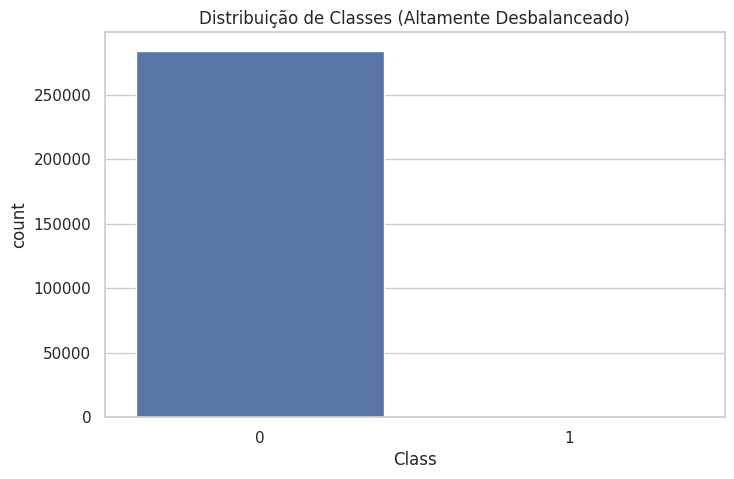

In [ ]:
df = pd.read_csv('../data/creditcard.csv')
print(f"Formato do dataset: {df.shape}")
print("\nDistribuição das Classes (0: Legítima, 1: Fraude):")
print(df['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df)
plt.title('Distribuição de Classes (Altamente Desbalanceado)')
plt.show()

## 3. Pré-processamento
Normalização das variáveis `Time` e `Amount` e divisão estratificada entre treino e teste (80/20).

In [3]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (227845, 30), Teste: (56962, 30)


## 4. Planejamento Experimental
Vamos comparar três abordagens:
1. **Baseline:** Random Forest sem balanceamento.
2. **Undersampling:** Random Forest com RandomUnderSampler.
3. **Hipótese (MVP):** XGBoost com SMOTE.

In [4]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    start_time = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_time
    
    start_inf = time.time()
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    inf_time = (time.time() - start_inf) / len(X_te) * 1000
    
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    cm = confusion_matrix(y_te, y_pred)
    fnr = cm[1, 0] / (cm[1, 0] + cm[1, 1]) # Taxa de Falsos Negativos
    
    return {
        'Experimento': name,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'FNR (Falsos Negativos)': fnr,
        'Tempo Treino (s)': train_time,
        'Inf. (ms/trans)': inf_time
    }, cm

results_list = []

### 4.1 Experimento 1: Baseline (Random Forest)

In [5]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
res, cm = evaluate_model("Baseline (RF)", rf_baseline, X_train, y_train, X_test, y_test)
results_list.append(res)
print(res)

{'Experimento': 'Baseline (RF)', 'F1-Score': 0.8743169398907104, 'AUC-ROC': 0.9630272515590367, 'FNR (Falsos Negativos)': np.float64(0.1836734693877551), 'Tempo Treino (s)': 46.12411069869995, 'Inf. (ms/trans)': 0.0030075138001364773}


### 4.2 Experimento 2: Undersampling + Random Forest

In [6]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)
res, cm = evaluate_model("Undersampling (RF)", rf_baseline, X_rus, y_rus, X_test, y_test)
results_list.append(res)
print(res)

{'Experimento': 'Undersampling (RF)', 'F1-Score': 0.08089887640449438, 'AUC-ROC': 0.9776977722715422, 'FNR (Falsos Negativos)': np.float64(0.08163265306122448), 'Tempo Treino (s)': 0.203812837600708, 'Inf. (ms/trans)': 0.0021800093803005286}


### 4.3 Experimento 3: SMOTE + XGBoost (Hipótese)

In [7]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
res, cm_xgb = evaluate_model("SMOTE + XGBoost", xgb_model, X_smote, y_smote, X_test, y_test)
results_list.append(res)
print(res)

# Salvar o melhor modelo
joblib.dump(xgb_model, 'results/best_model.pkl')

{'Experimento': 'SMOTE + XGBoost', 'F1-Score': 0.4941860465116279, 'AUC-ROC': 0.9759700552984278, 'FNR (Falsos Negativos)': np.float64(0.1326530612244898), 'Tempo Treino (s)': 1.9035301208496094, 'Inf. (ms/trans)': 0.000819706698322199}


['results/best_model.pkl']

## 5. Análise de Resultados
Comparação das métricas obtidas nos experimentos controlados.

,Experimento,F1-Score,AUC-ROC,FNR (Falsos Negativos),Tempo Treino (s),Inf. (ms/trans)
0,Baseline (RF),0.874317,0.963027,0.183673,46.124111,0.003008
1,Undersampling (RF),0.080899,0.977698,0.081633,0.203813,0.002180
2,SMOTE + XGBoost,0.494186,0.975970,0.132653,1.903530,0.000820


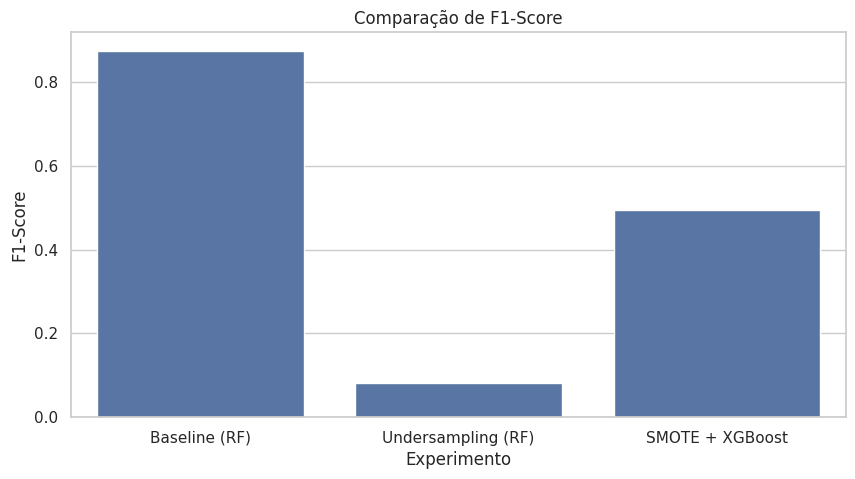

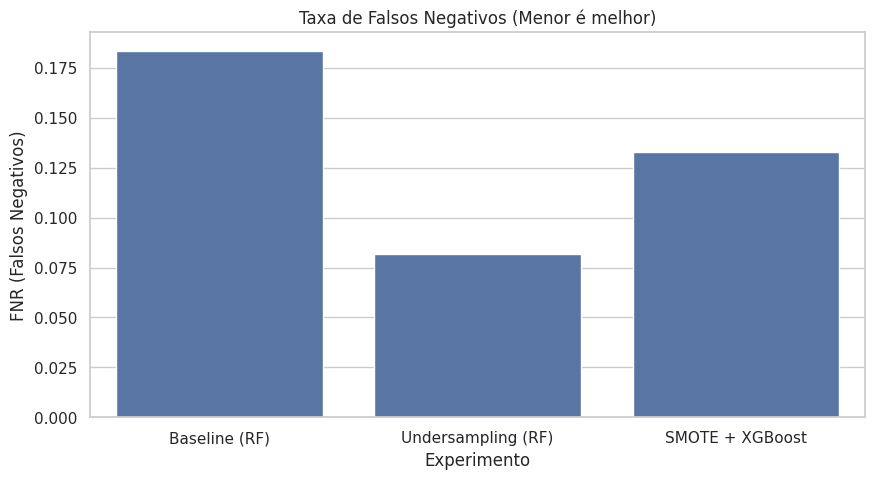

In [8]:
summary_df = pd.DataFrame(results_list)
display(summary_df)

# Gráfico de F1-Score
plt.figure(figsize=(10, 5))
sns.barplot(x='Experimento', y='F1-Score', data=summary_df)
plt.title('Comparação de F1-Score')
plt.show()

# Gráfico de FNR
plt.figure(figsize=(10, 5))
sns.barplot(x='Experimento', y='FNR (Falsos Negativos)', data=summary_df)
plt.title('Taxa de Falsos Negativos (Menor é melhor)')
plt.show()

## 6. Conclusão do MVP
Com base nos resultados, validamos se a hipótese de que **SMOTE + XGBoost** oferece o melhor equilíbrio entre detecção de fraudes e precisão. O modelo final foi exportado para uso em uma API funcional.